Installation and Import of Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Downloading the Dataset

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
# The file has no header, so we define column names
df = pd.read_table(url, header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Exploring Data

In [3]:
print(df.info())
print(df.describe())
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30
label
ham     4825
spam     747
Name: count, dtype: int64


Data Preprocessing

In [4]:
# Convert labels to numbers: ham = 0, spam = 1
df['label_num'] = df.label.map({'ham':0, 'spam':1})

# Define features (X) and target (y)
X = df.message
y = df.label_num

# Split the data into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Exploratory Data Analysis (EDA)

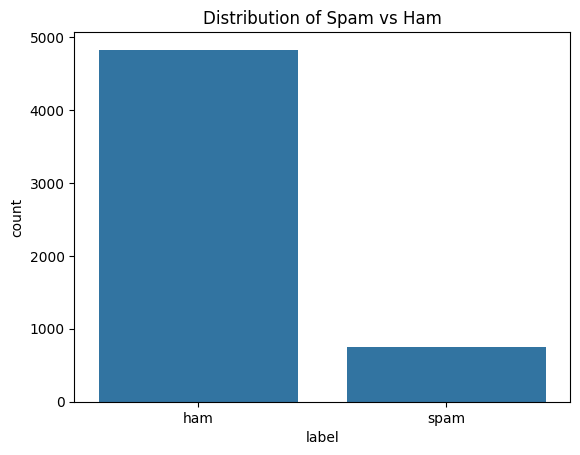

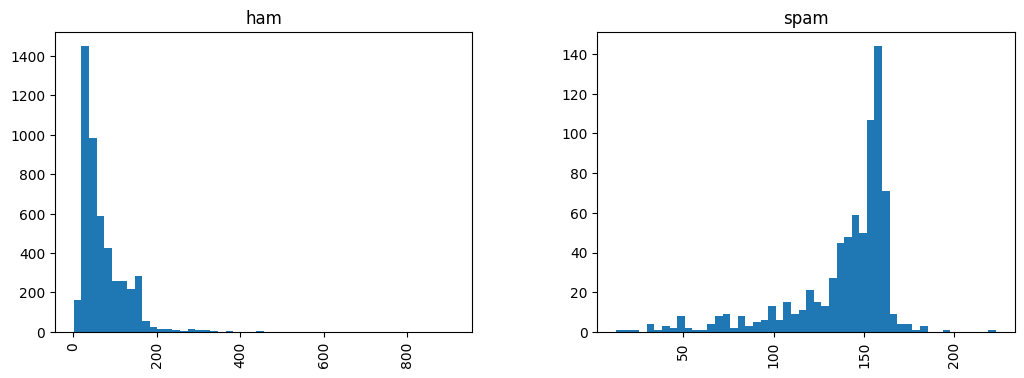

In [5]:
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham')
plt.show()

# Optional: Visualize message lengths
df['length'] = df['message'].apply(len)
df.hist(column='length', by='label', bins=50, figsize=(12,4))
plt.show()

Vectorization & Training the Model

In [6]:
# Initialize Vectorizer
vect = CountVectorizer(stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')

# Convert text into a document-term matrix
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Initialize and Train Naive Bayes Model
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

MultinomialNB()

Evaluating the Model

In [7]:
# Make predictions
y_pred = nb.predict(X_test_dtm)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 98.74%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.95      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



Visualizing Results

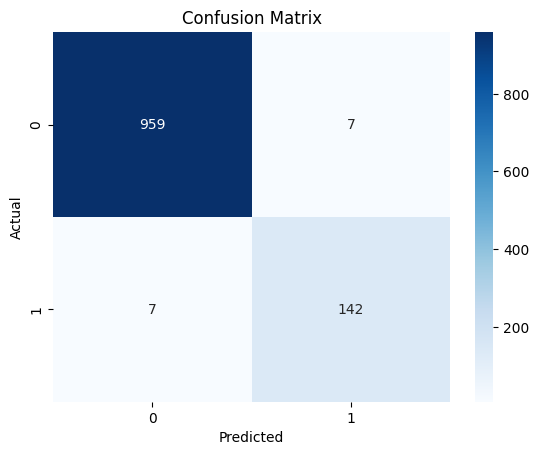

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Testing the Model (Manual Test)

In [9]:
def predict_spam(new_message):
    new_message_dtm = vect.transform([new_message])
    prediction = nb.predict(new_message_dtm)
    return "SPAM" if prediction[0] == 1 else "HAM"

# Test cases
print(predict_spam("Congratulations! You've won a $1,000 Walmart gift card. Click here to claim."))
print(predict_spam("Hey, meeting and  lunch at 12?"))
print(predict_spam("free lucky  prize meeting?"))

SPAM
HAM
SPAM


In [10]:
# Create a dataframe of all words with ham/spam log scores and probabilities

feature_names = vect.get_feature_names_out()

# Since ham=0 and spam=1 in your mapping
ham_log_scores = nb.feature_log_prob_[0]
spam_log_scores = nb.feature_log_prob_[1]

word_scores = pd.DataFrame({
    'word': feature_names,
    'ham_log_score': ham_log_scores,
    'spam_log_score': spam_log_scores
})

# Convert log probabilities to normal probabilities
word_scores['ham_prob'] = np.exp(word_scores['ham_log_score'])
word_scores['spam_prob'] = np.exp(word_scores['spam_log_score'])

# Normalize into percentages for comparison
word_scores['total_prob'] = word_scores['ham_prob'] + word_scores['spam_prob']
word_scores['ham_percent'] = (word_scores['ham_prob'] / word_scores['total_prob']) * 100
word_scores['spam_percent'] = (word_scores['spam_prob'] / word_scores['total_prob']) * 100

word_scores.head()

,word,ham_log_score,spam_log_score,ham_prob,spam_prob,total_prob,ham_percent,spam_percent
0,aah,-9.022111,-9.535029,0.000121,0.000072,0.000193,62.549022,37.450978
1,aaniye,-9.715259,-9.535029,0.000060,0.000072,0.000133,45.506422,54.493578
2,aaooooright,-9.715259,-9.535029,0.000060,0.000072,0.000133,45.506422,54.493578
3,aathi,-8.798968,-9.535029,0.000151,0.000072,0.000223,67.613398,32.386602
4,ab,-10.408406,-8.841882,0.000030,0.000145,0.000175,17.271252,82.728748


In [11]:
# Top 10 strongest spam words
top_spam_words = word_scores.sort_values(by='spam_percent', ascending=False)[
    ['word', 'spam_percent', 'ham_percent', 'spam_prob', 'ham_prob']
].head(10)

print("Top 10 Strongest Spam Words:")
print(top_spam_words.to_string(index=False))

print("\n" + "="*70 + "\n")

# Top 10 strongest ham words
top_ham_words = word_scores.sort_values(by='ham_percent', ascending=False)[
    ['word', 'ham_percent', 'spam_percent', 'ham_prob', 'spam_prob']
].head(10)

print("Top 10 Strongest Ham Words:")
print(top_ham_words.to_string(index=False))

Top 10 Strongest Spam Words:
      word  spam_percent  ham_percent  spam_prob  ham_prob
     claim     99.527764     0.472236   0.006360  0.000030
     prize     99.361732     0.638268   0.004698  0.000030
      tone     99.137628     0.862372   0.003469  0.000030
guaranteed     98.991878     1.008122   0.002963  0.000030
        cs     98.853466     1.146534   0.002602  0.000030
   awarded     98.750538     1.249462   0.002385  0.000030
        uk     98.580645     1.419355   0.004192  0.000060
  ringtone     98.580645     1.419355   0.002096  0.000030
       www     98.477109     1.522891   0.005854  0.000091
      rate     98.419462     1.580538   0.001879  0.000030


Top 10 Strongest Ham Words:
 word  ham_percent  spam_percent  ham_prob  spam_prob
   gt    99.065901      0.934099  0.007665   0.000072
   lt    99.062243      0.937757  0.007635   0.000072
  lor    98.120033      1.879967  0.003772   0.000072
   da    98.059091      1.940909  0.003652   0.000072
later    97.959892    

In [12]:
def check_word_scores(word):
    word = word.lower().strip()

    result = word_scores[word_scores['word'] == word]

    if result.empty:
        print(f'"{word}" is not present in the vocabulary learned by the model.')
    else:
        row = result.iloc[0]
        print(f'Word: {row["word"]}')
        print(f'Ham Log Score   : {row["ham_log_score"]:.6f}')
        print(f'Spam Log Score  : {row["spam_log_score"]:.6f}')
        print(f'Ham Probability : {row["ham_prob"]:.8f}')
        print(f'Spam Probability: {row["spam_prob"]:.8f}')
        print(f'Ham Percentage  : {row["ham_percent"]:.2f}%')
        print(f'Spam Percentage : {row["spam_percent"]:.2f}%')

In [13]:
check_word_scores("free")
check_word_scores("call")
check_word_scores("win")
check_word_scores("meeting")

Word: free
Ham Log Score   : -6.457162
Spam Log Score  : -4.293282
Ham Probability : 0.00156924
Spam Probability: 0.01366002
Ham Percentage  : 10.30%
Spam Percentage : 89.70%
"call" is not present in the vocabulary learned by the model.
Word: win
Ham Log Score   : -8.328964
Spam Log Score  : -5.509677
Ham Probability : 0.00024142
Spam Probability: 0.00404741
Ham Percentage  : 5.63%
Spam Percentage : 94.37%
Word: meeting
Ham Log Score   : -6.744844
Spam Log Score  : -9.535029
Ham Probability : 0.00117693
Spam Probability: 0.00007228
Ham Percentage  : 94.21%
Spam Percentage : 5.79%


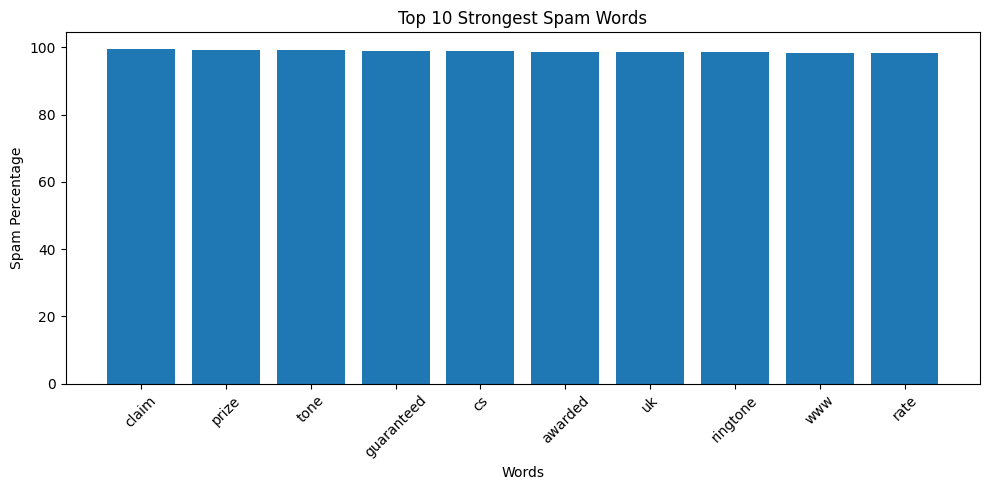

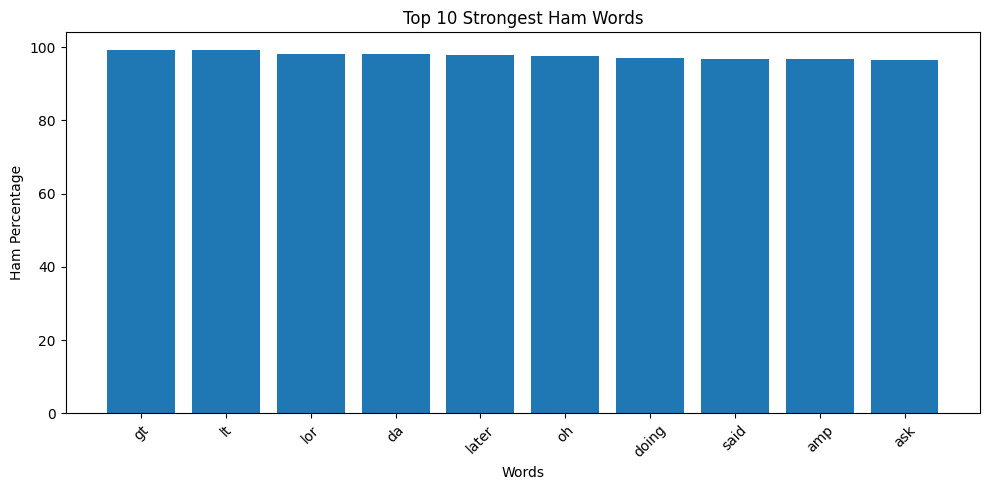

In [14]:
# Plot top 10 spam words
top_spam_plot = word_scores.sort_values(by='spam_percent', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_spam_plot['word'], top_spam_plot['spam_percent'])
plt.xticks(rotation=45)
plt.title("Top 10 Strongest Spam Words")
plt.xlabel("Words")
plt.ylabel("Spam Percentage")
plt.tight_layout()
plt.show()

# Plot top 10 ham words
top_ham_plot = word_scores.sort_values(by='ham_percent', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_ham_plot['word'], top_ham_plot['ham_percent'])
plt.xticks(rotation=45)
plt.title("Top 10 Strongest Ham Words")
plt.xlabel("Words")
plt.ylabel("Ham Percentage")
plt.tight_layout()
plt.show()

In [15]:
# Create clean_word_scores dataframe after filtering only alphabetic words

clean_word_scores = word_scores[word_scores['word'].str.isalpha()]

print(clean_word_scores.head())

          word  ham_log_score  spam_log_score  ham_prob  spam_prob  \
0          aah      -9.022111       -9.535029  0.000121   0.000072   
1       aaniye      -9.715259       -9.535029  0.000060   0.000072   
2  aaooooright      -9.715259       -9.535029  0.000060   0.000072   
3        aathi      -8.798968       -9.535029  0.000151   0.000072   
4           ab     -10.408406       -8.841882  0.000030   0.000145   

   total_prob  ham_percent  spam_percent  
0    0.000193    62.549022     37.450978  
1    0.000133    45.506422     54.493578  
2    0.000133    45.506422     54.493578  
3    0.000223    67.613398     32.386602  
4    0.000175    17.271252     82.728748  


In [16]:
top_spam_words = clean_word_scores.sort_values(
    by='spam_percent',
    ascending=False
).head(10)

print(top_spam_words[['word','spam_percent','ham_percent']])

            word  spam_percent  ham_percent
982        claim     99.527764     0.472236
4318       prize     99.361732     0.638268
5761        tone     99.137628     0.862372
2332  guaranteed     98.991878     1.008122
1240          cs     98.853466     1.146534
389      awarded     98.750538     1.249462
5903          uk     98.580645     1.419355
4676    ringtone     98.580645     1.419355
6370         www     98.477109     1.522891
4465        rate     98.419462     1.580538


In [17]:
top_ham_words = clean_word_scores.sort_values(
    by='ham_percent',
    ascending=False
).head(10)

print(top_ham_words[['word','ham_percent','spam_percent']])

       word  ham_percent  spam_percent
2329     gt    99.065901      0.934099
3251     lt    99.062243      0.937757
3211    lor    98.120033      1.879967
1282     da    98.059091      1.940909
3037  later    97.959892      2.040108
3838     oh    97.462806      2.537194
1530  doing    96.905505      3.094495
4757   said    96.691782      3.308218
182     amp    96.691782      3.308218
314     ask    96.548765      3.451235


In [18]:
# Full Statement Spam/Ham Probability Prediction
def predict_message_with_probability(message):
    message_dtm = vect.transform([message])
    prediction = nb.predict(message_dtm)[0]
    probabilities = nb.predict_proba(message_dtm)[0]

    print("\nMessage:", message)
    print("Prediction:", "SPAM" if prediction == 1 else "HAM")
    print(f"Ham Probability : {probabilities[0]*100:.2f}%")
    print(f"Spam Probability: {probabilities[1]*100:.2f}%")

In [21]:
user_message = input("Enter a message: ")
predict_message_with_probability(user_message)

Enter a message: Hi John, Are you also getting some message mentioning free price money ?

Message: Hi John, Are you also getting some message mentioning free price money ?
Prediction: HAM
Ham Probability : 94.21%
Spam Probability: 5.79%
